# The CIFAR-10 Dataset
The [CIFAR-10 and the CIFAR-100](https://www.cs.toronto.edu/~kriz/cifar.html) datastes are important benchmarks in image processing. Here we will  build, train, and evaluate a feedforward neural network on the CIFAR‑10 dataset using TensorFlow.

**Objective:**
Design and implement a feedforward neural network to classify images in the CIFAR‑10 dataset. You will preprocess the data, build and train the model, evaluate its performance, and answer analytical questions regarding the design choices and possible enhancements.

The CIFAR-10 dataset consists of 60000 32x32 color images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

Task 1:

1. Load the Dataset:
  * Import TensorFlow and the necessary modules from Keras.
  * Load the CIFAR‑10 dataset using the `cifar10.load_data()` method in the `kears` module. As the link says, this dataset is approximately 163 Mb and might take some time to download.
  * Use the `imshow()` method in Pyplot to visualize 10 randomly selected train and test images. If the images look too grainy, play around with the `interpolation` argument to smooth out pixel values.

2. Normalize the Data:
  * Convert the image pixel values from integers to floats.
  * Scale the images such that pixel values are in the range [0, 1].

3. ~~Flatten and~~ One‑Hot Encode:
  * ~~Reshape each 32x32x3 image into a 3072‑dimensional vector.~~
  * Convert the labels to one‑hot encoding for 10 classes using the `to_categorical()` method in [Kears](https://keras.io/api/utils/).

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

/Users/jirissman/Documents/coursework/BU/CS767/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f"Training set: {x_train.shape}, Test set: {x_test.shape}")

Training set: (50000, 32, 32, 3), Test set: (10000, 32, 32, 3)


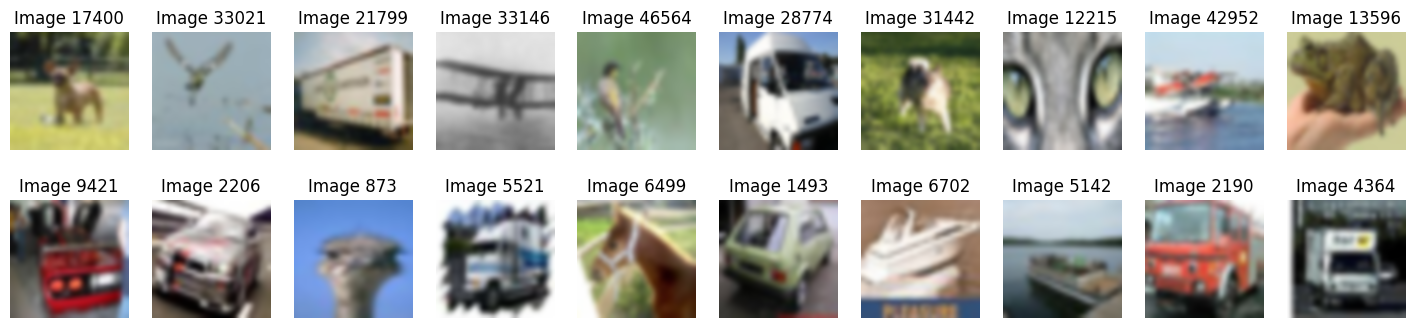

In [3]:
plt.figure(figsize=(18, 8))
for i in range(10):
    idx_train = np.random.randint(0, len(x_train))
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[idx_train], interpolation='bicubic')
    plt.title(f"Image {idx_train}")
    plt.axis('off')
    idx_test = np.random.randint(0, len(x_test))
    plt.subplot(2, 10, i+11)
    plt.imshow(x_test[idx_test], interpolation='bicubic')
    plt.title(f"Image {idx_test}")
    plt.axis('off')
plt.show()

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [5]:
y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

## Building the Neural Network Model
Task 2:

1. An input layer of size 32×32×3 (since the images have 3 channels, viz, red, blue, and green).

2. First convolutional + maxpooling block: 32 filters of size 3×3 each. Use “same” padding to preserve output size for all convolutional layers in this network and ReLU activations. Use maxpooling blocks of size (2×2) throughout your network. Let’s stick with stride = 1 everywhere for simplicity.

3. Second convolutional + maxpooling block: 64 filters of size 3×3 each.

4. Third convolutional + maxpooling block: 128 filters of size 3×3 each.

5. `flatten` the output of this layer and feed it to a dense layer with 128 units (and ReLU activation).

6. The final layer is a fully connected layer with SoftMax activation and 10 outputs (one for each class of CIFAR10).


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

This model has a total of 2,629,130 weights.

## Model Training and Evaluation
Task 3:

1. Train the Model:
  * Train the model for 20 epochs with a batch size of 128.
  * Use the test data as validation data during training (pass `validation_data`).

2. Evaluate the Model:
  * Evaluate the model on the test set.
  * Print and report the test loss and test accuracy.

In [9]:
history = model.fit(
    x_train, y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test_onehot),
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.3273 - loss: 1.8313 - val_accuracy: 0.5422 - val_loss: 1.2796
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - accuracy: 0.5634 - loss: 1.2215 - val_accuracy: 0.6000 - val_loss: 1.1239
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.6444 - loss: 1.0122 - val_accuracy: 0.6680 - val_loss: 0.9659
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.6947 - loss: 0.8802 - val_accuracy: 0.6870 - val_loss: 0.9160
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.7310 - loss: 0.7796 - val_accuracy: 0.7060 - val_loss: 0.8514
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.7504 - loss: 0.7144 - val_accuracy: 0.7024 - val_loss: 0.8970
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - accuracy: 0.7707 - loss: 0.6515 - val_accuracy: 0.7347 - val_loss: 0.7886
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.7953 - loss: 0.5888 

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_onehot, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 1.1525
Test accuracy: 0.7403


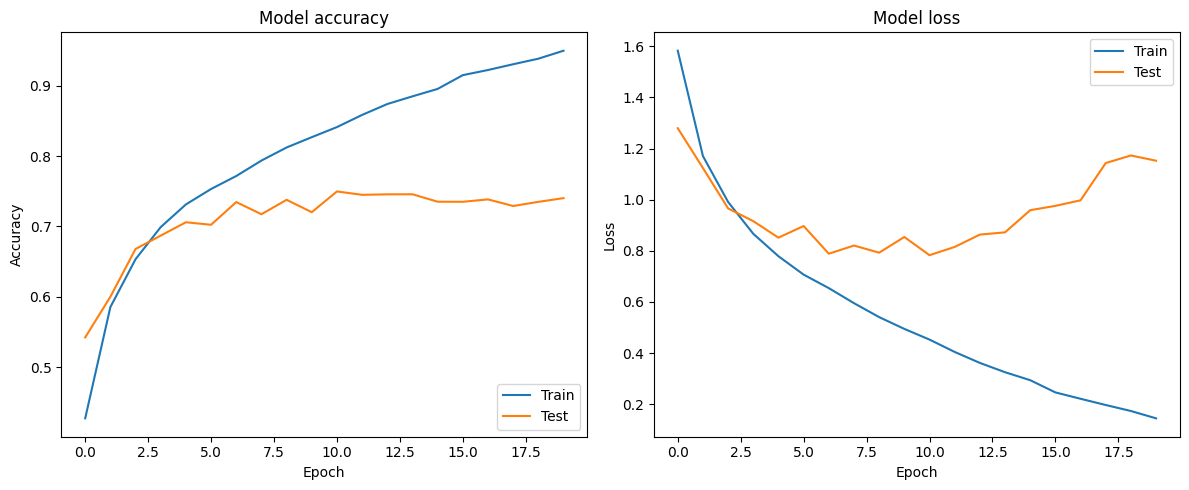

Final training accuracy: 0.9500
Final test accuracy: 0.7403


In [11]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.tight_layout()
plt.show()

print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final test accuracy: {history.history['val_accuracy'][-1]:.4f}")

Compile the model with the Adam optimizer and show the Accuracy vs Epoch plot as before. How many parameters does this model have? How does it compare with your earlier feedforward network? What are the final train and test accuracy values this model achieves? How do they compare with your earlier feedforward network?

* The model has 356,810 parameters.
* The convolutional nueral network outperformed the feedforward neural network, with higher test accuracy and lower test loss.
* The final training and test accuracies are 0.9500 and 0.7403, respectively.
* The feedforward network had final training and test accuracies of 0.6849 and 0.5041, respectively. This shows a very significant improvement for the convolutional neural network.